In [1]:
# Hucre 1: Setup
from google.colab import drive
drive.mount('/content/drive')

!pip install -q grad-cam==1.5.4

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import torch
import cv2

PROJECT = Path('/content/drive/MyDrive/DR_Project')
SRC = PROJECT / 'src'
CHECKPOINTS = PROJECT / 'checkpoints'
FIG = PROJECT / 'reports' / 'figures'
SPLITS = PROJECT / 'splits'
APTOS = PROJECT / 'datasets' / 'APTOS'
sys.path.insert(0, str(SRC))

# Albumentations + smp dependencies (yeni session ise gerekli)
!pip install -q --no-deps albumentations==1.4.18

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

import importlib
import preprocessing, dataset, models
for m in [preprocessing, dataset, models]:
    importlib.reload(m)

from models import create_model
from dataset import CLASS_NAMES, get_val_transforms
from preprocessing import preprocess_pipeline, get_normalization_stats

# Best classifier yukle
ckpt = torch.load(CHECKPOINTS / 'best_classifier.pth',
                  map_location=device, weights_only=False)
model = create_model('efficientnet_b3', num_classes=5, pretrained=False,
                     drop_rate=0.3).to(device)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f"Model yuklendi (epoch {ckpt['epoch']})")
print(f"Val metrikleri: {ckpt['val_metrics']}")

# pytorch-grad-cam
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
print("grad-cam import OK")

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 50.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.0/224.0 kB 5.6 MB/s eta 0:00:00
Device: cpu


/usr/local/lib/python3.12/dist-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Model yuklendi (epoch 19)
Val metrikleri: {'accuracy': 0.8076398362892224, 'f1_macro': 0.6559377321608632, 'kappa_quadratic': np.float64(0.8850327002046798), 'avg_loss': 1.175309155298316}
grad-cam import OK


In [1]:
# Hucre 1: Setup
from google.colab import drive
drive.mount('/content/drive')

!pip install -q grad-cam==1.5.4

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import torch
import cv2

PROJECT = Path('/content/drive/MyDrive/DR_Project')
SRC = PROJECT / 'src'
CHECKPOINTS = PROJECT / 'checkpoints'
FIG = PROJECT / 'reports' / 'figures'
SPLITS = PROJECT / 'splits'
APTOS = PROJECT / 'datasets' / 'APTOS'
sys.path.insert(0, str(SRC))

# Albumentations + smp dependencies (yeni session ise gerekli)
!pip install -q --no-deps albumentations==1.4.18

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

import importlib
import preprocessing, dataset, models
for m in [preprocessing, dataset, models]:
    importlib.reload(m)

from models import create_model
from dataset import CLASS_NAMES, get_val_transforms
from preprocessing import preprocess_pipeline, get_normalization_stats

# Best classifier yukle
ckpt = torch.load(CHECKPOINTS / 'best_classifier.pth',
                  map_location=device, weights_only=False)
model = create_model('efficientnet_b3', num_classes=5, pretrained=False,
                     drop_rate=0.3).to(device)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f"Model yuklendi (epoch {ckpt['epoch']})")
print(f"Val metrikleri: {ckpt['val_metrics']}")

# pytorch-grad-cam
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
print("grad-cam import OK")

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 70.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.0/224.0 kB 10.3 MB/s eta 0:00:00
Device: cuda


/usr/local/lib/python3.12/dist-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Model yuklendi (epoch 19)
Val metrikleri: {'accuracy': 0.8076398362892224, 'f1_macro': 0.6559377321608632, 'kappa_quadratic': np.float64(0.8850327002046798), 'avg_loss': 1.175309155298316}
grad-cam import OK


Her sinif icin ornek seciliyor...
  Sinif 0 (No DR): 5b2648ad455e.png (prob=0.918)
  Sinif 1 (Mild): 3ee17aa12e46.png (prob=0.978)
  Sinif 2 (Moderate): 4b5ffea77373.png (prob=0.977)
  Sinif 3 (Severe): 8a9bef2fbd4e.png (prob=0.992)
  Sinif 4 (PDR): 838c87c63422.png (prob=0.996)


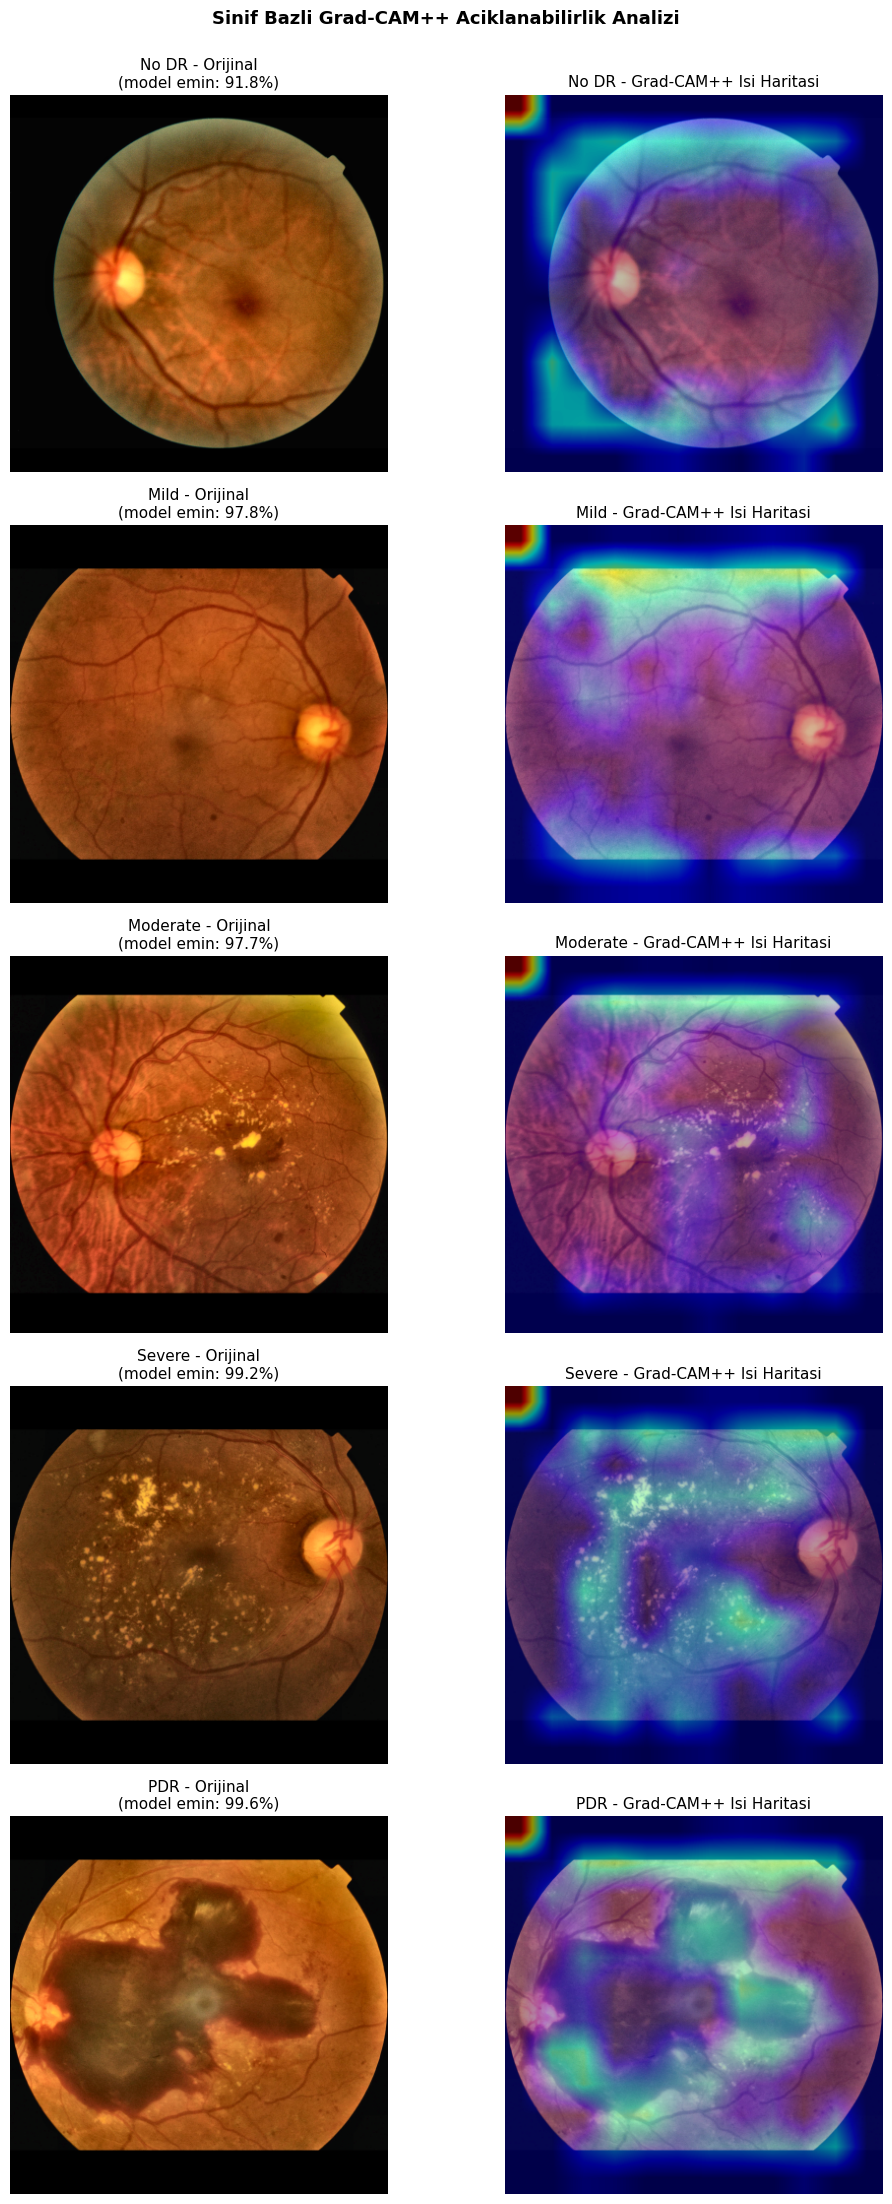


Kaydedildi: /content/drive/MyDrive/DR_Project/reports/figures/fig_gradcam.png


In [2]:
# Hucre 2: Her sinif icin Grad-CAM ornekleri
val_df = pd.read_csv(SPLITS / 'val.csv')

# Her siniftan en yuksek olasilikli (model'in en emin oldugu) ornegi sec
val_tf = get_val_transforms(384)
stats = get_normalization_stats()
mean = np.array(stats['mean']); std = np.array(stats['std'])

def load_and_prep(img_path):
    """Goruntu yukle, preprocess, normalize, tensor yap. Hem display hem model icin."""
    img_rgb = preprocess_pipeline(img_path, size=384, apply_clahe_flag=True)
    aug = val_tf(image=img_rgb)
    tensor = aug['image']  # (3,384,384) normalize
    display_rgb = img_rgb.astype(np.float32) / 255.0  # for overlay
    return tensor, display_rgb

# Sinif basina aday say, model olasiligina gore sirala
print("Her sinif icin ornek seciliyor...")
samples_per_class = {}
for cls in range(5):
    candidates = val_df[val_df['label'] == cls].sample(min(20, len(val_df[val_df['label']==cls])),
                                                       random_state=42)
    best_score = -1
    best_row = None
    for _, row in candidates.iterrows():
        t, _ = load_and_prep(row['image_path'])
        x = t.unsqueeze(0).to(device)
        with torch.no_grad():
            logits = model(x)
            probs = torch.softmax(logits, dim=1)[0]
        score = probs[cls].item()
        if score > best_score:
            best_score = score
            best_row = row
    samples_per_class[cls] = (best_row, best_score)
    print(f"  Sinif {cls} ({CLASS_NAMES[cls]}): {Path(best_row['image_path']).name} "
          f"(prob={best_score:.3f})")

# Grad-CAM++ kullanalim (daha keskin)
# EfficientNet-B3 son conv layer'i: model.blocks[-1] veya model.conv_head
target_layers = [model.conv_head]
cam = GradCAMPlusPlus(model=model, target_layers=target_layers)

# 5 sinif x 2 sutun (orijinal, heatmap overlay)
fig, axes = plt.subplots(5, 2, figsize=(11, 22))

for i, cls in enumerate(range(5)):
    row, prob = samples_per_class[cls]
    tensor, display_rgb = load_and_prep(row['image_path'])
    input_tensor = tensor.unsqueeze(0).to(device)

    # Grad-CAM heatmap (kendi sinifina karsi)
    targets = [ClassifierOutputTarget(cls)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]  # (384,384)

    # Overlay
    cam_img = show_cam_on_image(display_rgb, grayscale_cam, use_rgb=True,
                                image_weight=0.55)

    axes[i, 0].imshow(display_rgb)
    axes[i, 0].set_title(f'{CLASS_NAMES[cls]} - Orijinal\n'
                         f'(model emin: {prob*100:.1f}%)', fontsize=11)
    axes[i, 0].axis('off')
    axes[i, 1].imshow(cam_img)
    axes[i, 1].set_title(f'{CLASS_NAMES[cls]} - Grad-CAM++ Isi Haritasi',
                         fontsize=11)
    axes[i, 1].axis('off')

plt.suptitle('Sinif Bazli Grad-CAM++ Aciklanabilirlik Analizi',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(FIG / 'fig_gradcam.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\nKaydedildi: {FIG / 'fig_gradcam.png'}")